In [2]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from RENDES_fizinfo import *

In [3]:
# Gy / 12. feladat [16 p]
# Egy pingpong-labda mozgását vizsgáljuk többféle kísérletben. 
# A szabványos átmérő 40 mm, a tömeg pedig 2,7 g. 
# A labda rugalmas állandóját 1000 N/m-nek vehetjük, 
# a talajjal való kölcsönhatás közbeni fékezőerőt pedig 0,2 N-nak.

# a) Ábrázolja egy pingpong-labda hely-, 
# sebesség- és gyorsulás-idő függvényét a talajra érésig, 
# ha egy lépcsőházban 25 m magasról kezdősebesség nélkül ejtjük le! (4 p)

# b) Milyen lesz a labda pályája az első 20 másodpercben, 
# ha 40 km/h kezdősebességgel, a vízszinteshez képest 30 fokos szögben indítjuk, 
# a talaj felett 110 cm-ről? (4 p)

# c) Határozza meg a földet érési helyek időpontjait, 
# és egy kis táblázatban print() parancsokkal adja meg ezek időpontját, 
# x koordinátáját és a földnek csapódás sebességét! (4 p)

# d) A b) pontbeli paraméterekből mindent megtartunk,
# csak a kezdősebesség nagyságát változtatjuk 0 és 100 km/h közt. 
# Ábrázolja a kezdősebesség függvényében azt, 
# milyen x koordinátáig jut el a labda 20 s alatt! (4 p)

In [4]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):
    """
    Visszaadja egy labda erő- és tömegfüggvényét gravitáció,
    közegellenállás és rugalmas talajtól való visszapattanás figyelembevételével.

    Paraméterek:
        m    : labda tömege [kg]
        C    : közegellenállási együttható (C_D)
        A    : labda homlokfelülete [m²]
        rho  : közeg sűrűsége [kg/m³]
        D    : rugalmas talajmodell merevségi együtthatója [N/m]
              (talaj-reakcióerő: F_talaj = D * behatolás, ha y <= 0)
        F_f  : súrlódási erő nagysága a talajon [N]
              (vízszintes irányban lassít, ha a labda érinti a talajt)
        g    : gravitációs gyorsulás [m/s²]
    """

    def tomeg_fuggveny(t):
        # A labda tömege állandó (nincs tömegváltozás)
        return m

    def ero_fuggveny(t, helyzet, sebesseg, tomeg):
        """
        Az összes erő eredője [N], 2D vektorként (x, y).

        Hatások:
          - gravitáció         : lefelé (y irány)
          - közegellenállás    : sebességgel ellentétes, v²-tel arányos
          - talaj reakcióerő   : felfelé, ha y <= 0 (rugalmas behatolás)
          - talaj súrlódás     : vízszintes irányban, ha y <= 0
        """

        eredo_ero = np.array([0.0, 0.0], dtype=np.float64)

        # --- Gravitációs erő ---
        eredo_ero[1] -= tomeg * g                          # F_g = -m·g (y irányban lefelé)

        # --- Közegellenállási erő ---
        sebesseg_nagysag = np.sqrt((sebesseg ** 2).sum())  # |v| [m/s]
        if sebesseg_nagysag > 1e-10:
            eredo_ero -= 0.5 * C * A * rho \
                         * sebesseg * sebesseg_nagysag     # F_drag = ½·C·A·ρ·v·|v|, iránya: -v̂

        # --- Talaj reakcióerő (rugalmas ütközésmodell) ---
        y = helyzet[1]
        vy = sebesseg[1]
        if y <= 0.0:                        # labda elérte / átment a talajon
            behatolas = -y                  # behatolás mélysége [m] (pozitív)
            eredo_ero[1] += D * behatolas   # F_talaj = D · δ (felfelé)

            # Talaj súrlódás: csak ha a labda érinti a talajt és mozog vízszintesen
            vx = sebesseg[0]
            if abs(vx) > 1e-10:
                eredo_ero[0] -= F_f * np.sign(vx)    # F_súrl = -F_f · sign(vx)

        return eredo_ero

    return ero_fuggveny, tomeg_fuggveny

# --- Labda fizikai paraméterei ---
m_pingpong = 0.0027            # labda tömege [kg]
#perim_ball   = 0.76          # labda kerülete [m]
atmero_ball  = 0.040         # labda átmérője [m]

r   = atmero_ball/2              # labda sugara [m]
A   = np.pi * r**2               # homlokfelület (keresztmetszet) [m²]
C   = 0.47                       # közegellenállási együttható (gömb)
rho = 1.3                        # levegő sűrűsége [kg/m³]
g   = 9.81                       # gravitációs gyorsulás [m/s²]

# --- Talajmodell paraméterei ---
D   = 1000.0   # rugalmas talaj merevségi együtthatója [N/m]
F_f = 0.2      # talaj súrlódási erő [N]

# --- Erő- és tömegfüggvény példányosítása ---
ero_fuggveny, tomeg_fuggveny = create_grav_közeg_talaj_F_m(m_pingpong, C, A, rho, D, F_f, g)

In [5]:
# --- Kezdőfeltételek ---
kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 25  # kezdeti y pozíció [m] (1.8 m magasról indítjuk)

indulo_sebesseg     = 0   # kezdeti sebesség nagysága [m/s]
indulo_szog_fok     = 90.0   # indulási szög (vízszintestől) [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

ball_din = num_dinam(2)                     # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 30.0, 0.0001)    # t ∈ [0, 20] s, dt = 0,001 s


ball_din.set_F_fun(ero_fuggveny)           # erőfüggvény (gravitáció + drag + tolóerő)
ball_din.set_mass_fun(tomeg_fuggveny)      # tömegfüggvény (hajtóanyag-fogyás)
ball_din.set_r0_v0([kezdo_x, kezdo_y],     # kezdeti helyzet:  [0 m, 1.8 m]
                     [kezdo_vx, kezdo_vy]) # kezdeti sebesség: 55°, 10 m/s

# Egyszerű leállási feltétel: ha y<0, akkor stop
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0
ball_din.set_stop_cond(stop_ground_y)      # a fenti függvény megadása

# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)
ball_din.clip_below_y()
ball_din.calc_r_to_v()

# --- Pályagörbe megjelenítése ---
#ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán

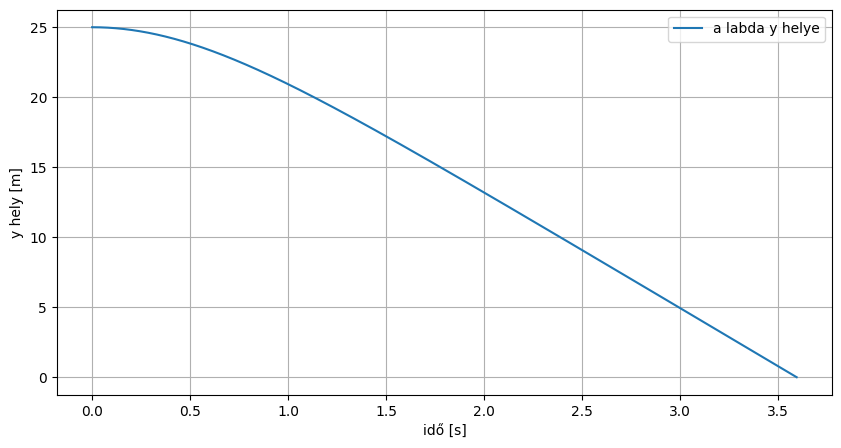

In [6]:
# a) Ábrázolja egy pingpong-labda hely-, 
# sebesség- és gyorsulás-idő függvényét a talajra érésig, 
# ha egy lépcsőházban 25 m magasról kezdősebesség nélkül ejtjük le! (4 p)

fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(ball_din.t, ball_din.r_y, label='a labda y helye')

ax1.set_xlabel('idő [s]')
ax1.set_ylabel('y hely [m]')
ax1.legend()
ax1.grid()

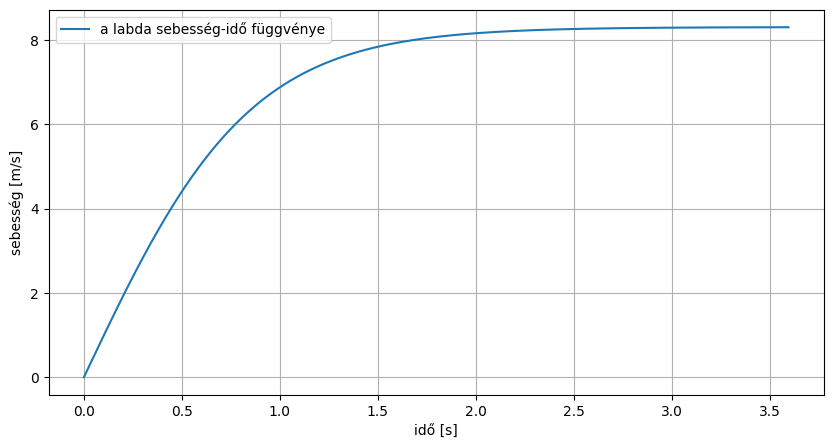

In [7]:
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(ball_din.t, ball_din.v_abs, label='a labda sebesség-idő függvénye')
ax1.set_xlabel('idő [s]')
ax1.set_ylabel('sebesség [m/s]')
ax1.legend()
ax1.grid()

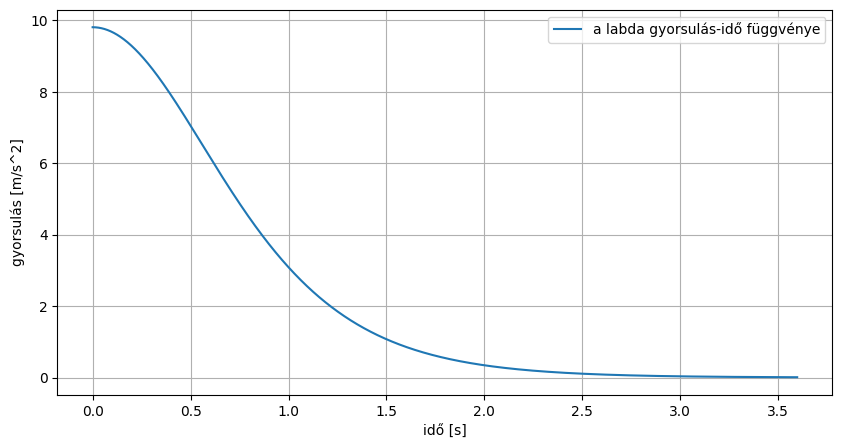

In [8]:
fig = plt.figure(figsize=(10, 5))
ax1 = plt.subplot(111)

ax1.plot(ball_din.t, ball_din.a_abs, label='a labda gyorsulás-idő függvénye')
ax1.set_xlabel('idő [s]')
ax1.set_ylabel('gyorsulás [m/s^2]')
ax1.legend()
ax1.grid()

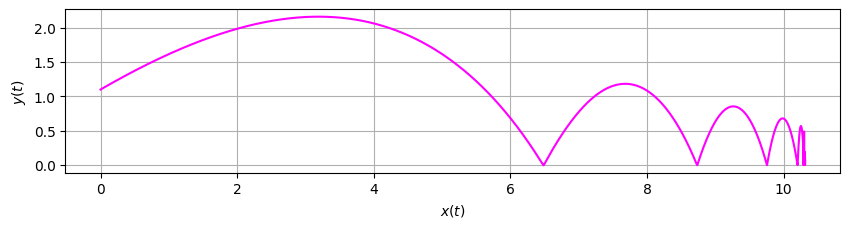

In [9]:
# b) Milyen lesz a labda pályája az első 20 másodpercben, 
# ha 40 km/h kezdősebességgel, a vízszinteshez képest 30 fokos szögben indítjuk, 
# a talaj felett 110 cm-ről? (4 p)

# --- Kezdőfeltételek ---
kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 1.1  # kezdeti y pozíció [m] (110 cm magasról indítjuk)

indulo_sebesseg     = 40.0 / 3.6  # 40km/h / 3.6 kezdeti sebesség nagysága [m/s]
indulo_szog_fok     = 30.0   # indulási szög (vízszintestől) [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

ball_din = num_dinam(2)                     # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 20.0, 0.0001)    # t ∈ [0, 20] s, dt = 0,001 s


ball_din.set_F_fun(ero_fuggveny)           # erőfüggvény (gravitáció + drag + tolóerő)
ball_din.set_mass_fun(tomeg_fuggveny)      # tömegfüggvény (hajtóanyag-fogyás)
ball_din.set_r0_v0([kezdo_x, kezdo_y],     # kezdeti helyzet:  [0 m, 1.8 m]
                     [kezdo_vx, kezdo_vy]) # kezdeti sebesség: 55°, 10 m/s

# Egyszerű leállási feltétel: ha y<0, akkor stop
def stop_ground_y(r, v):
    """Leállás y<0 esetén"""
    
    return r[1]<0.0
#ball_din.set_stop_cond(stop_ground_y)      # a fenti függvény megadása

# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)
#ball_din.clip_below_y()
ball_din.calc_r_to_v()

# --- Pályagörbe megjelenítése ---
ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán

In [10]:
# c) Határozza meg a földet érési helyek időpontjait, 
# és egy kis táblázatban print() parancsokkal adja meg ezek időpontját, 
# x koordinátáját és a földnek csapódás sebességét! (4 p)

# foldeteresek amikor v = 0
ind_foldet_er = arg_eq(ball_din.r_y, 0.0)

# Csak azok kellenek ahol lefelé megy (vy < 0), ne a felfelé pattanások
ind_foldet_er = [i for i in ind_foldet_er if ball_din.v_y[i] < 0.05]

# Csak ha az előző pattanástól legalább 0.1 m-t mozdult
ind_szurt = [ind_foldet_er[0]]
for i in ind_foldet_er[1:]:
    if ball_din.r_x[i] - ball_din.r_x[ind_szurt[-1]] > 0.001:
        ind_szurt.append(i)

print(f"{'időpont':>12}      {'x':>10}          {'sebesség':>12}")
print("-" * 50)
for i in ind_szurt:
    print(f'időpont: {ball_din.t[i]:.2f} s  \t'
          f'x: {ball_din.r_x[i]:.2f} m  \t'
          f'v: {ball_din.v_abs[i]:.2f} m/s')

     időpont               x              sebesség
--------------------------------------------------
időpont: 1.16 s  	x: 6.48 m  	v: 6.31 m/s
időpont: 2.14 s  	x: 8.73 m  	v: 4.74 m/s
időpont: 2.98 s  	x: 9.75 m  	v: 3.98 m/s
időpont: 3.73 s  	x: 10.20 m  	v: 3.51 m/s
időpont: 4.42 s  	x: 10.30 m  	v: 3.20 m/s
időpont: 10.33 s  	x: 10.30 m  	v: 1.91 m/s
időpont: 10.72 s  	x: 10.30 m  	v: 1.86 m/s
időpont: 11.10 s  	x: 10.30 m  	v: 1.81 m/s
időpont: 11.47 s  	x: 10.31 m  	v: 1.77 m/s
időpont: 11.83 s  	x: 10.31 m  	v: 1.73 m/s
időpont: 12.18 s  	x: 10.31 m  	v: 1.69 m/s
időpont: 12.53 s  	x: 10.31 m  	v: 1.66 m/s
időpont: 12.87 s  	x: 10.31 m  	v: 1.62 m/s
időpont: 13.20 s  	x: 10.31 m  	v: 1.59 m/s


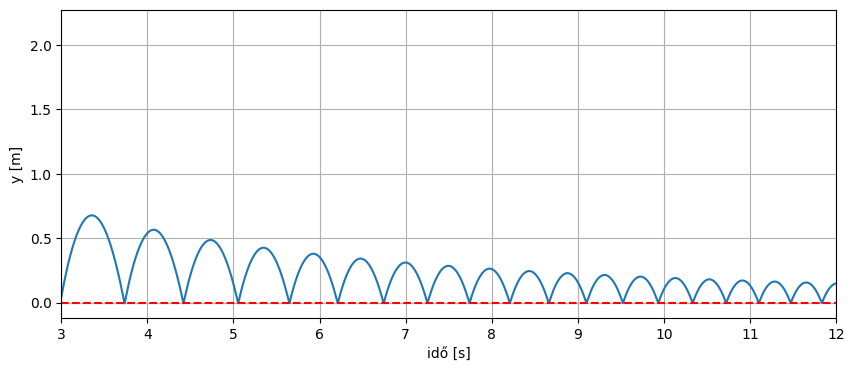

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ball_din.t, ball_din.r_y)
ax.axhline(0, color='r', linestyle='--')
ax.set_xlim(3, 12)  # a gyanús tartomány
ax.set_xlabel('idő [s]')
ax.set_ylabel('y [m]')
ax.grid()

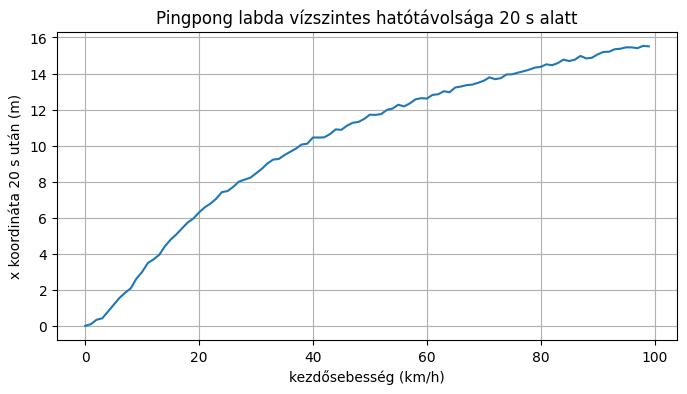

In [12]:
# Gy/12d: A kezdősebesség nagyságát változtatjuk 0–100 km/h között (30°-os szögben indítva),
# és ábrázoljuk, milyen x koordinátáig jut el a labda 20 s alatt.
# Fizikai háttér: nagyobb kezdősebesség → több mozgási energia → messzebb jut,
# de a közegellenállás és a pattanások energiavesztesége miatt nem lineáris a kapcsolat.
def pingpong_20s(v0_kmh):
    # --- Labda és közeg paraméterei (azonosak a b) pontbeliekkel) ---
    m   = 0.0027              # labda tömege [kg] (pingpong labda)
    A   = np.pi*(0.040/2)**2  # homlokfelület [m²] (40 mm átmérő)
    C   = 0.47                # közegellenállási együttható (gömb)
    rho = 1.3                 # levegő sűrűsége [kg/m³]
    D   = 1000.0              # rugalmas talaj merevsége [N/m]
    F_f = 0.2                 # talaj súrlódási erő [N]
    g   = 9.81                # gravitációs gyorsulás [m/s²]

    ero_fuggveny, tomeg_fuggveny = create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g)

    szog = np.radians(30.0)  # kilövési szög [°] → [rad]
    v0   = v0_kmh / 3.6      # km/h → m/s átváltás

    labda = num_dinam(2)
    labda.set_time_param(0.0, 20.0, 0.0005)  # dt = 0.0005 s (finom rács a pattanásokhoz)
    labda.set_mass_fun(tomeg_fuggveny)
    labda.set_F_fun(ero_fuggveny)
    labda.set_r0_v0(
        np.array([0.0, 1.1]),                         # kezdeti hely: [0 m, 1.1 m]
        np.array([v0*np.cos(szog), v0*np.sin(szog)])  # kezdeti sebesség: 30°-os irányban
    )
    labda.set_stop_cond(None)  # nincs leállási feltétel: pontosan 20 s-ig fut
    labda.full_dinam_calc()
    return labda.r_x[-1]       # x koordináta 20 s után [m]

# --- Paramétersöprés: 0–100 km/h, 51 egyenletes lépésben ---
sebessegek = np.arange(0.0, 100.0, 1.0)  # kezdősebességek [km/h]
vegso_x = np.array([pingpong_20s(v) for v in sebessegek])

plt.figure(figsize=(8, 4))
plt.plot(sebessegek, vegso_x)
plt.xlabel('kezdősebesség (km/h)')
plt.ylabel('x koordináta 20 s után (m)')
plt.title('Pingpong labda vízszintes hatótávolsága 20 s alatt')
plt.grid()
plt.show()